# Phase 1 — Data Generation

This notebook explores the LTE network simulation that produced the training dataset.

**What's covered:**
- Network layout (base station positions)
- Radio model — RSRP, SINR, RSRQ, CQI
- UE mobility (pedestrian vs vehicle)
- A3-event handover trigger logic
- Dataset statistics and label balance

In [1]:
import sys, math
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DATA = '../data/raw/dataset.csv'
df = pd.read_csv(DATA)
print(f'Shape: {df.shape}')
df.head()

Shape: (27000, 16)


,timestamp,ue_id,serving_cell_id,rsrp_serving,rsrq_serving,sinr,cqi,best_neighbor_cell_id,rsrp_neighbor,rsrq_neighbor,ue_speed,pos_x,pos_y,handover_event,target_cell_id,handover_soon
0,0,0,2,-57.02,-3.0,5.24,6,3,-62.88,-6.99,1.77,443.88,821.36,0,-1,0
1,1,0,2,-55.59,-3.0,5.73,6,3,-61.57,-7.01,1.77,442.65,820.08,0,-1,0
2,2,0,2,-58.73,-3.0,3.81,5,3,-63.26,-6.03,1.77,441.05,819.30,0,-1,0
3,3,0,2,-55.42,-3.0,7.41,7,3,-63.28,-8.58,1.77,439.63,818.25,0,-1,0
4,4,0,2,-55.03,-3.0,6.03,7,3,-61.46,-7.40,1.77,437.93,817.74,0,-1,0


## 1. Network Layout

4 base stations are placed at symmetric positions on a 1000 × 1000 m grid.

| BS | X (m) | Y (m) |
|----|-------|-------|
| 0  | 250   | 250   |
| 1  | 750   | 250   |
| 2  | 250   | 750   |
| 3  | 750   | 750   |

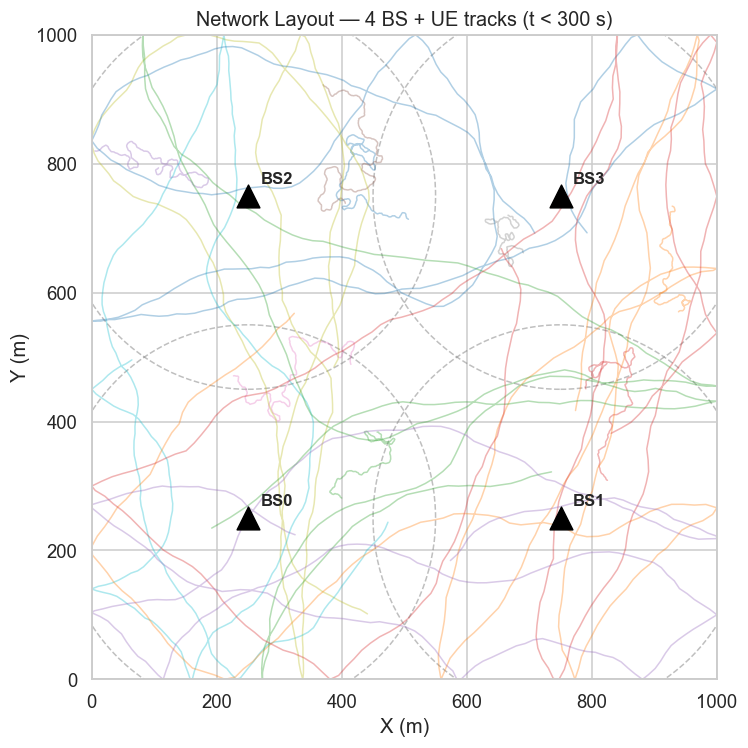

In [2]:
BS_POSITIONS = {0: (250, 250), 1: (750, 250), 2: (250, 750), 3: (750, 750)}
COLORS = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(7, 7))

# UE tracks (first 300 steps for clarity)
sample = df[df['timestamp'] < 300]
for ue_id in sorted(sample['ue_id'].unique()):
    ue = sample[sample['ue_id'] == ue_id]
    ax.plot(ue['pos_x'], ue['pos_y'], alpha=0.35, lw=1, color=COLORS[ue_id % 10])

# Base stations
for bs_id, (bx, by) in BS_POSITIONS.items():
    ax.scatter(bx, by, s=220, marker='^', color='black', zorder=5)
    ax.annotate(f'BS{bs_id}', (bx, by), textcoords='offset points',
                xytext=(8, 8), fontsize=11, fontweight='bold')
    circle = plt.Circle((bx, by), 300, fill=False,
                         linestyle='--', linewidth=1, color='gray', alpha=0.5)
    ax.add_patch(circle)

ax.set_xlim(0, 1000); ax.set_ylim(0, 1000)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title('Network Layout — 4 BS + UE tracks (t < 300 s)', fontsize=13)
plt.tight_layout(); plt.show()

## 2. Radio Model

**Path loss** (3GPP TR 25.814 Urban Macro):

$$PL = 128.1 + 37.6 \cdot \log_{10}(d_{km}) \quad [\text{dB}]$$

$$RSRP = P_{tx} - PL + \mathcal{N}(0, \sigma^2) \quad [\text{dBm}]$$

At 100 m → RSRP ≈ −44 dBm · At 500 m → RSRP ≈ −71 dBm

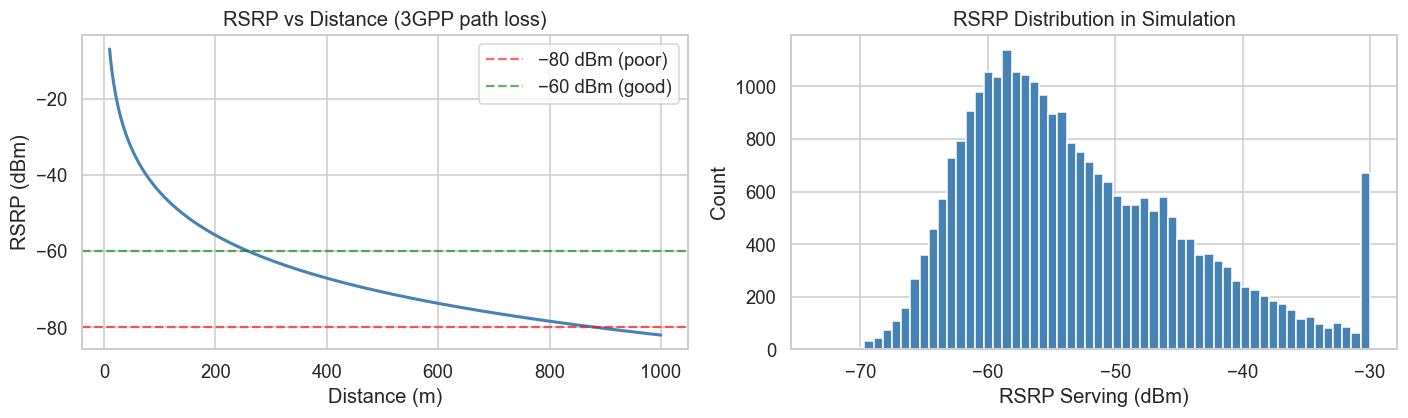

In [3]:
d = np.linspace(10, 1000, 500)
pl = 128.1 + 37.6 * np.log10(np.maximum(d, 1) / 1000)
rsrp = 46 - pl

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(d, rsrp, color='steelblue', lw=2)
axes[0].axhline(-80, ls='--', color='red',   alpha=0.6, label='−80 dBm (poor)')
axes[0].axhline(-60, ls='--', color='green', alpha=0.6, label='−60 dBm (good)')
axes[0].set_xlabel('Distance (m)'); axes[0].set_ylabel('RSRP (dBm)')
axes[0].set_title('RSRP vs Distance (3GPP path loss)'); axes[0].legend()

axes[1].hist(df['rsrp_serving'], bins=60, color='steelblue', edgecolor='white')
axes[1].set_xlabel('RSRP Serving (dBm)'); axes[1].set_ylabel('Count')
axes[1].set_title('RSRP Distribution in Simulation')

plt.tight_layout(); plt.show()

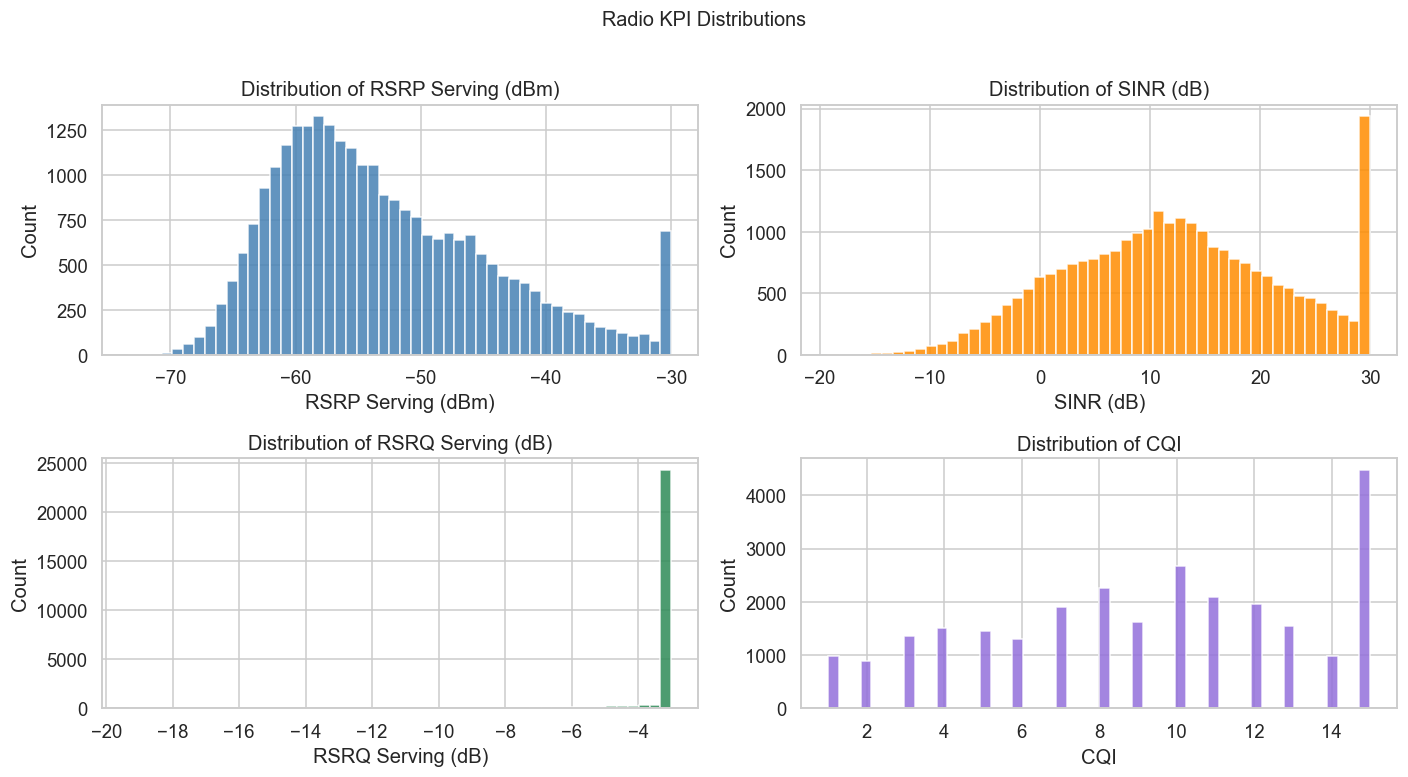

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
pairs = [
    ('rsrp_serving', 'RSRP Serving (dBm)', 'steelblue'),
    ('sinr',         'SINR (dB)',           'darkorange'),
    ('rsrq_serving', 'RSRQ Serving (dB)',   'seagreen'),
    ('cqi',          'CQI',                 'mediumpurple'),
]
for ax, (col, label, c) in zip(axes.flat, pairs):
    ax.hist(df[col], bins=50, color=c, edgecolor='white', alpha=0.85)
    ax.set_xlabel(label); ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {label}')
plt.suptitle('Radio KPI Distributions', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 3. UE Mobility

- **Pedestrian UEs (0–7):** 1–2 m/s, high heading variance (random-walk dominant)
- **Vehicle UEs (8–14):** 10–20 m/s, low heading variance (mostly linear)

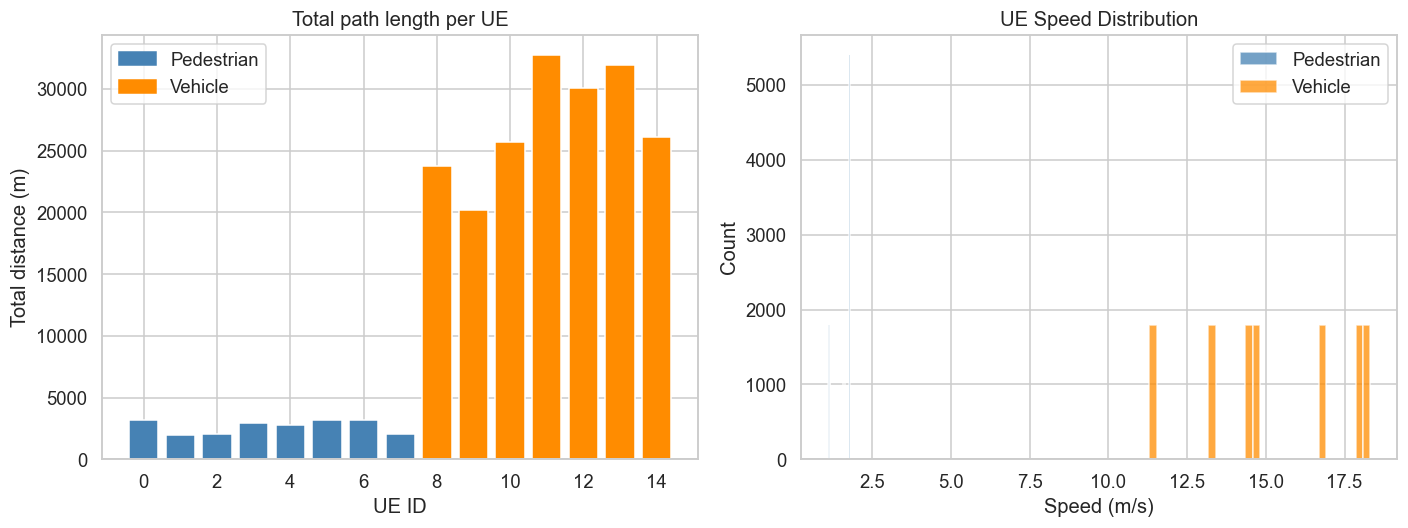

In [5]:
speed_profile = df[['ue_id','ue_speed']].drop_duplicates('ue_id').set_index('ue_id')['ue_speed']
ue_types = ['Vehicle' if s > 3 else 'Pedestrian' for s in speed_profile]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trajectory length comparison
traj_len = df.groupby('ue_id').apply(
    lambda g: np.sqrt(np.diff(g['pos_x'])**2 + np.diff(g['pos_y'])**2).sum()
)
colors_bar = ['darkorange' if t == 'Vehicle' else 'steelblue' for t in ue_types]
axes[0].bar(speed_profile.index, traj_len.values, color=colors_bar)
axes[0].set_xlabel('UE ID'); axes[0].set_ylabel('Total distance (m)')
axes[0].set_title('Total path length per UE')
patches = [mpatches.Patch(color='steelblue', label='Pedestrian'),
           mpatches.Patch(color='darkorange', label='Vehicle')]
axes[0].legend(handles=patches)

# Speed distribution
axes[1].hist(df[df['ue_speed'] < 5]['ue_speed'],  bins=30, label='Pedestrian',
             color='steelblue', alpha=0.75, edgecolor='white')
axes[1].hist(df[df['ue_speed'] >= 5]['ue_speed'], bins=30, label='Vehicle',
             color='darkorange', alpha=0.75, edgecolor='white')
axes[1].set_xlabel('Speed (m/s)'); axes[1].set_ylabel('Count')
axes[1].set_title('UE Speed Distribution'); axes[1].legend()

plt.tight_layout(); plt.show()

## 4. Handover Logic (A3 Event)

A handover is triggered when:

$$RSRP_{\text{neighbor}} > RSRP_{\text{serving}} + \underbrace{3\,\text{dB}}_{\text{margin}}$$

for **TTT = 3 consecutive steps**. The RSRP gap at trigger time is typically 3–8 dB.

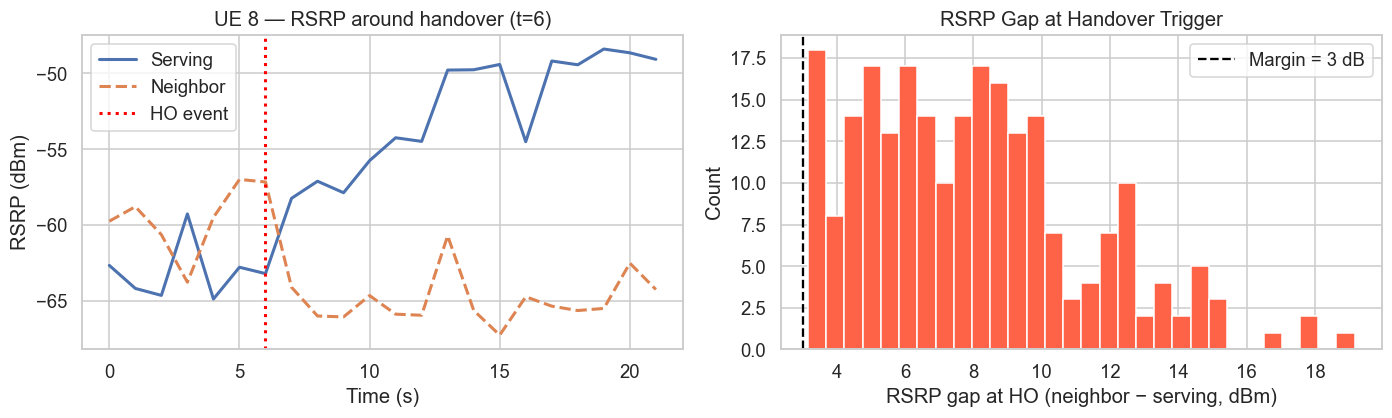

In [6]:
ho = df[df['handover_event'] == 1].copy()
ho['rsrp_gap'] = ho['rsrp_neighbor'] - ho['rsrp_serving']

# RSRP trace for one vehicle UE around a handover
vehicle_ues = df[df['ue_speed'] > 3]['ue_id'].unique()
ue_ho = ho[ho['ue_id'].isin(vehicle_ues)]
if len(ue_ho) > 0:
    example_ue = int(ue_ho['ue_id'].iloc[0])
    example_t  = int(ue_ho['timestamp'].iloc[0])
    window = df[(df['ue_id'] == example_ue) &
                (df['timestamp'].between(example_t - 15, example_t + 15))]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(window['timestamp'], window['rsrp_serving'],  label='Serving',  lw=2)
    axes[0].plot(window['timestamp'], window['rsrp_neighbor'], label='Neighbor', lw=2, ls='--')
    ho_rows = window[window['handover_event'] == 1]
    axes[0].axvline(example_t, color='red', ls=':', lw=2, label='HO event')
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('RSRP (dBm)')
    axes[0].set_title(f'UE {example_ue} — RSRP around handover (t={example_t})')
    axes[0].legend()

    axes[1].hist(ho['rsrp_gap'], bins=30, color='tomato', edgecolor='white')
    axes[1].axvline(3, ls='--', color='black', label='Margin = 3 dB')
    axes[1].set_xlabel('RSRP gap at HO (neighbor − serving, dBm)')
    axes[1].set_ylabel('Count'); axes[1].set_title('RSRP Gap at Handover Trigger')
    axes[1].legend()

    plt.tight_layout(); plt.show()

## 5. Dataset Statistics & Label Balance

In [7]:
print('=== Dataset Overview ===')
print(f'Rows          : {len(df):,}')
print(f'UEs           : {df["ue_id"].nunique()}')
print(f'Timesteps     : {df["timestamp"].nunique()}')
print(f'Handover events : {df["handover_event"].sum()}')
print(f'\nhandover_soon=1 : {df["handover_soon"].sum()} ({df["handover_soon"].mean()*100:.1f}%)')
print(f'handover_soon=0 : {(df["handover_soon"]==0).sum()} ({(1-df["handover_soon"].mean())*100:.1f}%)')

print('\n=== Signal Ranges ===')
print(df[['rsrp_serving','rsrq_serving','sinr','cqi','rsrp_neighbor','ue_speed']]
      .agg(['min','max','mean','std']).round(2))

=== Dataset Overview ===
Rows          : 27,000
UEs           : 15
Timesteps     : 1800
Handover events : 236

handover_soon=1 : 708 (2.6%)
handover_soon=0 : 26292 (97.4%)

=== Signal Ranges ===
      rsrp_serving  rsrq_serving   sinr    cqi  rsrp_neighbor  ue_speed
min         -73.29        -19.31 -19.26   1.00         -81.03      1.09
max         -30.00         -3.00  30.00  15.00         -46.45     18.32
mean        -52.93         -3.29  12.19   9.19         -67.22      7.89
std           8.63          1.14   9.82   4.20           4.78      7.05


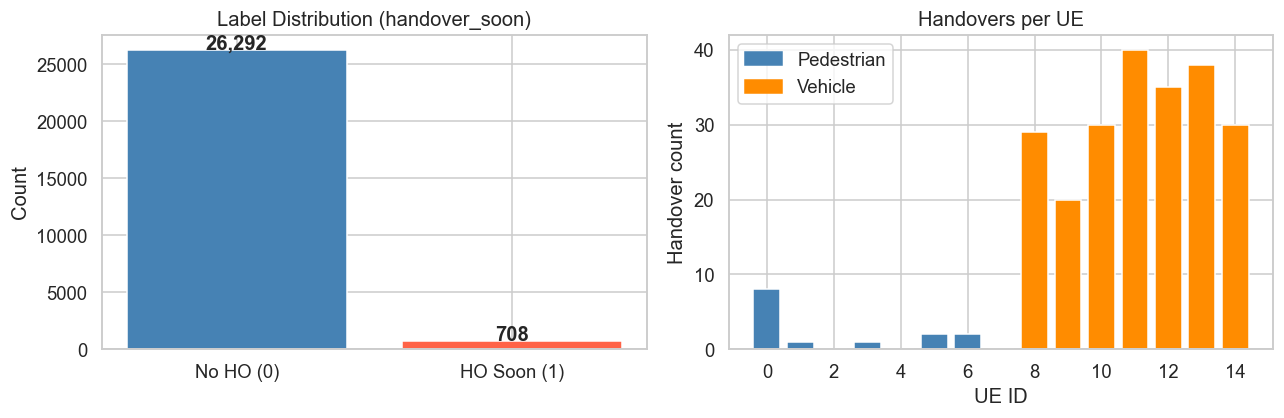

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
counts = df['handover_soon'].value_counts()
axes[0].bar(['No HO (0)', 'HO Soon (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Label Distribution (handover_soon)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# HO events per UE
ho_per_ue = df.groupby('ue_id')['handover_event'].sum()
speed_map = df[['ue_id','ue_speed']].drop_duplicates('ue_id').set_index('ue_id')['ue_speed']
bar_colors = ['darkorange' if speed_map[u] > 3 else 'steelblue' for u in ho_per_ue.index]
axes[1].bar(ho_per_ue.index, ho_per_ue.values, color=bar_colors)
axes[1].set_xlabel('UE ID'); axes[1].set_ylabel('Handover count')
axes[1].set_title('Handovers per UE')
axes[1].legend(handles=[
    mpatches.Patch(color='steelblue', label='Pedestrian'),
    mpatches.Patch(color='darkorange', label='Vehicle')])

plt.tight_layout(); plt.show()

## Summary

| Item | Value |
|------|-------|
| Dataset rows | 27,000 |
| Positive labels | ~2.6% |
| Handover events | 236 |
| RSRP range | −73 to −30 dBm |
| SINR range | −19 to +30 dB |

Vehicle UEs generate far more handovers due to faster cell-boundary crossings.

→ **Next:** [02_feature_engineering.ipynb](02_feature_engineering.ipynb)